import the necessary libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

set notebook environmental variable for style

In [2]:
sns.set_style('ticks')
sns.set_style('whitegrid')

import the dataset to be analyzed and store it in dataframe variable, df

In [3]:
df = pd.read_csv("chickwts.csv")
df

,Unnamed: 0,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean
...,...,...,...
66,67,359,casein
67,68,216,casein
68,69,222,casein
69,70,283,casein


data analysis - Imported Dataset (chickwts.csv)
----------------------------------
The dataset looks like clean structured raw data with no missing values and no apparent format issues. The raw data is clean.

 compute mean weight per feed type, sorted

In [4]:
df.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

data analysis - Mean Weight of Chicks Per Feed
----------------------------------
We see in the raw data that casein and sunflower have significantly higher averages than the other feeds. Also, horsebean is significantly lower mean weight than all the other feed's mean weight.

Bar-chart mean weight by feed, fully labeled with a title that states the takeaway and a y-axis in grams

In [5]:
df_sorted_mean = df.groupby("feed")["weight"].mean().sort_values()
ordered_categories = df_sorted_mean.index.tolist()
df['feed'] = pd.Categorical(df['feed'], categories=ordered_categories, ordered=True)

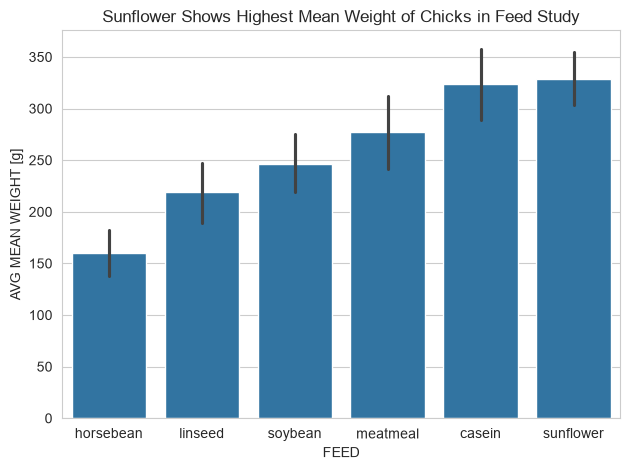

<Figure size 960x720 with 0 Axes>

In [6]:
sns.barplot(x='feed', y='weight', data=df)
plt.title('Sunflower Shows Highest Mean Weight of Chicks in Feed Study')
plt.xlabel("FEED")
plt.ylabel("AVG MEAN WEIGHT [g]")
plt.tight_layout()
plt.figure(dpi=150.0)
plt.savefig('FeedStudy_SunflowerHighestMeanWt_BarGrph.png')
plt.show()

data analysis - Bar Plot of Average Mean Weight of Chicks in Feed 
Study
----------------------------------
We see in the box plot a visualization of our assumption while examining tbe raw data - that casein and sunflower have significantly higher averages than the other feeds. Also, horsebean is significantly lower mean weight than all the other feed's mean weight.

Histogram of 'weight' variable

<Axes: xlabel='weight', ylabel='Count'>

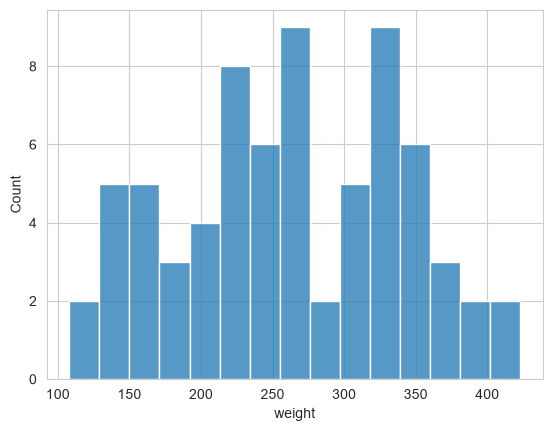

In [7]:
sns.histplot(data=df, x="weight", bins=15)

data analysis - Histogram of Average Mean Weight of Chicks in Feed 
Study
----------------------------------
We see in the histogram plot as expected a roughly symmetric distribution centered near 260 g.

load museum_visitors.csv

In [8]:
df1 = pd.read_csv("museum_visitors.csv")
df1

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694
5,2014-06-01,29487,5751,2121,11036
6,2014-07-01,32378,5406,2239,13490
7,2014-08-01,37680,8619,1769,9139
8,2014-09-01,28473,61192,1073,5661
9,2014-10-01,27995,6488,1979,7356


data analysis - Imported Dataset (museum_visitors.csv)
----------------------------------
The dataset looks like clean structured raw data with no missing values and no apparent format issues. The raw data is clean.

plot a line-chart visitors vs. time

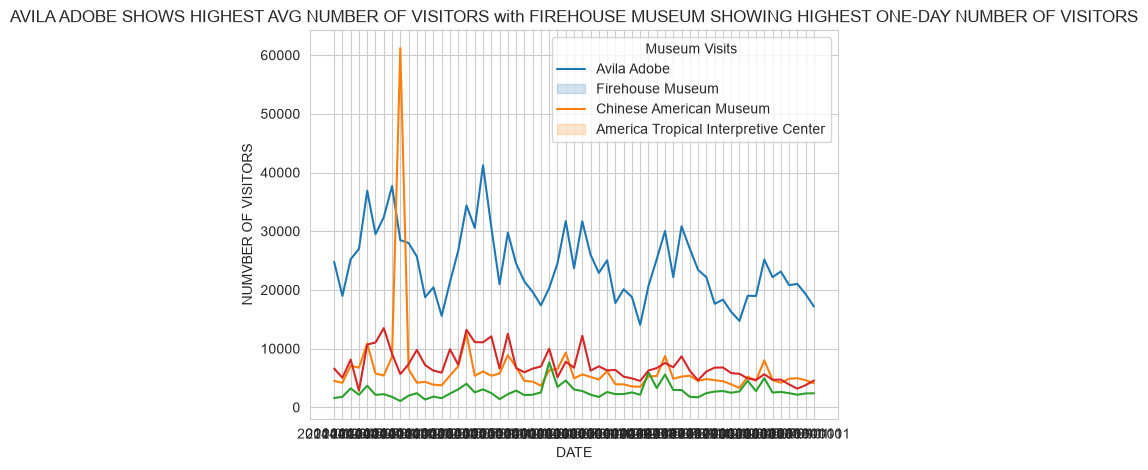

<Figure size 960x720 with 0 Axes>

In [9]:
sns.lineplot(data=df1, x="Date", y="Avila Adobe")
sns.lineplot(data=df1, x="Date", y="Firehouse Museum")
sns.lineplot(data=df1, x="Date", y="Chinese American Museum")
sns.lineplot(data=df1, x="Date", y="America Tropical Interpretive Center")
plt.title('AVILA ADOBE SHOWS HIGHEST AVG NUMBER OF VISITORS with FIREHOUSE MUSEUM SHOWING HIGHEST ONE-DAY NUMBER OF VISITORS')
plt.xlabel("DATE")
plt.ylabel("NUMVBER OF VISITORS")
plt.legend( labels=df1.columns.tolist()[1: ], title="Museum Visits", loc="upper right", frameon=True)
plt.tight_layout()
plt.figure(dpi=150.0)
plt.savefig('MuseumVisitors_HighestAvgHighestOneDay_LinePlot.png')
plt.show()



data analysis - Line Chart of Museum Visits Over Time
----------------------------------
The line plot clearly shows two distinct characteristics. For one, we se the blue line represented by Avila Adobe as having the highest average museum visits consistently over time when compared to the number of visits at the other museums. Next, we see a spike in the data for Firehouse Museums tracking of visitors over time. This spike tells us that the highes daily visit belongs toFirehouse Museums and the relative time period that the spike to place.

imort module 4's data

In [10]:
df2 = pd.read_csv("truck.csv")
df2

,X,Y
0,12.400000,11.200000
1,14.300000,12.500000
2,14.500000,12.700000
3,14.900000,13.100000
4,16.100000,14.100000
5,16.900000,14.800000
6,16.500000,14.400000
7,15.400000,13.400000
8,17.000000,14.900000
9,17.900000,15.600000


 scatter qty vs. revenue

<Axes: xlabel='X', ylabel='Y'>

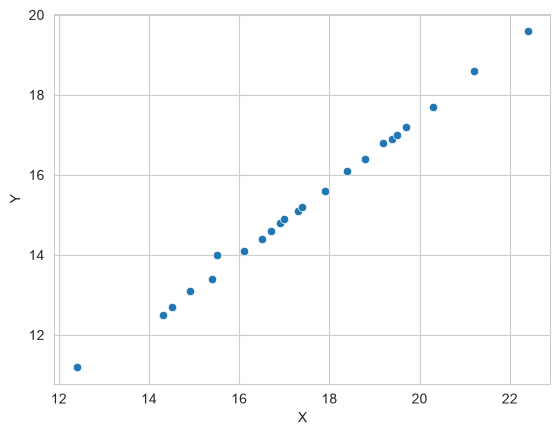

In [11]:
sns.scatterplot(data=df2, x="X", y="Y")

data analysis - Scatter Plot of Quantity Sold Over Revenue
----------------------------------
We see a positive, linear, very high correlation of data of Quatity vs. Revenue. This stands to reason based on the direct proportionality of selling a higher quantity and generating a higher revenue.

 make a correlation heatmap

<Axes: >

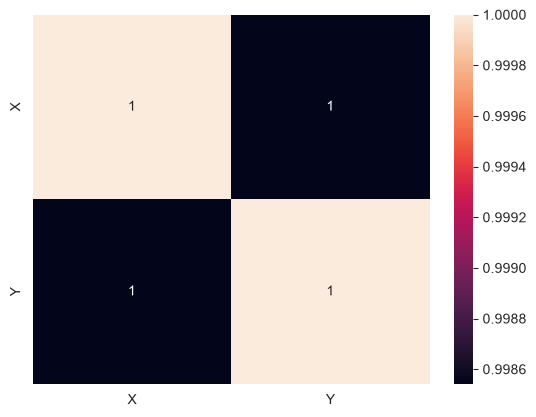

In [12]:
sns.heatmap(df2.corr(numeric_only=True), annot=True)

data analysis - Correlation Heat Map of Quantity Sold Over Revenue
----------------------------------
The Correlation Heat Map matches the correlation matrix of module 4, as expected, since the heat map is showing regions oif highest values color-coded to the same regios of the correlation matrix.

Compare Sunflower-Fed and Horsebean-Fed Chicks
------------------------------------------------------
1. Write the null hypothesis: There is no difference in the mean weight of chicks who were sunflower-fed and horsebean-fed.
2. Extract the two feed groups’ weights and run ttest_ind()

perform the t-test

In [13]:
df.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

In [14]:
sunflower_data = df[df["feed"] == "sunflower"]["weight"]
horsebean_data = df[df["feed"] == "horsebean"]["weight"]

In [15]:
# Python program to conduct Welch's t-Test

In [16]:
t_test_result = stats.ttest_ind(sunflower_data , horsebean_data, equal_var = False )

In [17]:
print('t-test results')
print(f't-value: {t_test_result.statistic}')
print(f'p-value: {t_test_result.pvalue}')

t-test results
t-value: 9.044878424622727
p-value: 1.6903886311534453e-08


data analysis - p-value Assesment
======================================
the p-value is much less than 0.05

calculate the mean diff's

In [18]:
mean_diff = np.mean(sunflower_data) - np.mean(horsebean_data)

calculate the confidence interval

In [19]:
conf_interval = stats.t.interval(
    0.95, len(sunflower_data) + len(horsebean_data) - 2, loc=mean_diff, scale=stats.sem(np.concatenate((sunflower_data, horsebean_data)))
)

In [20]:
print(f'95 percent confidence interval: {conf_interval}')
print(f'mean of classA: {np.mean(sunflower_data)}')
print(f'mean of classB: {np.mean(horsebean_data)}')

95 percent confidence interval: (np.float64(125.86944486455596), np.float64(211.56388846877744))
mean of classA: 328.9166666666667
mean of classB: 160.2


data analysis - Confidence Interval
======================================
mean weight of chicks fed with sunflower is 328.9166666666667 grams vs a mean weight of chicks fed with horsebean is 160.2 grams, 
that is approximately 169 g mean weight difference between the two groups, that is nearly a 2:1 ratio, with a 95% interval from 125.87g to 211.56, p =1.6903886311534453e-08.

URL for This Assignmemnt's Repo
================================================================================

https://github.com/chillyvee70/cs82a-portfolio/tree/main/module5